In [2]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import model_train

✅ Model saved!


Overall Accuracy: 98.94%

Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99     23481
        true       0.99      0.99      0.99     21417

    accuracy                           0.99     44898
   macro avg       0.99      0.99      0.99     44898
weighted avg       0.99      0.99      0.99     44898



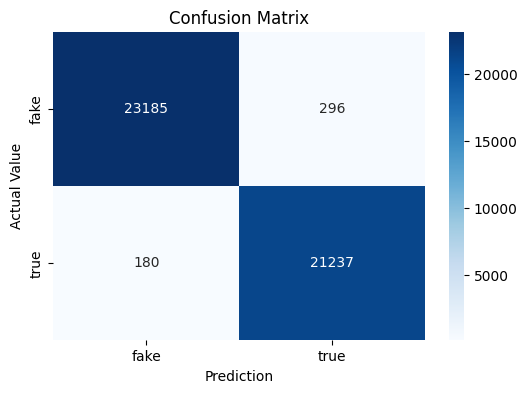

In [3]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_fake = pd.read_csv('data/Fake.csv')
df_true = pd.read_csv('data/True.csv')

# Add labels
df_fake['label'] = 'fake'
df_true['label'] = 'true'

# Combine datasets
df = pd.concat([df_fake, df_true], ignore_index=True)
X = df['text']
y = df['label']

# ## Load trained model and vectorizer

# %% 
model = joblib.load('modelo_fake_news.pkl')
vectorizer = joblib.load('vectorizer.pkl')

# Transform texts
X_tfidf = vectorizer.transform(X)


# ## Make predictions and calculate metrics

y_pred = model.predict(X_tfidf)
acc = accuracy_score(y, y_pred)
print(f"Overall Accuracy: {acc:.2%}\n")

print("Classification Report:")
print(classification_report(y, y_pred, target_names=['fake', 'true']))

# ## Confusion Matrix

cm = confusion_matrix(y, y_pred, labels=['fake', 'true'])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fake', 'true'], yticklabels=['fake', 'true'])
plt.xlabel('Prediction')
plt.ylabel('Actual Value')
plt.title('Confusion Matrix')
plt.show()
